In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

## Plot attendees and emissions of Vancouver, Rome and Singpore in one plot

People attending Vancouver: 2776.0
super long haul flights Vancouver: 672.0
long haul flights Vancouver: 2104.0
short haul Vancouver: 0
residence flights Vancouver: 0
People attending Singapore: 2038
super long haul flights Singapore: 1136
long haul flights Singapore: 777
short haul Singapore: 1
residence flights Singapore: 124
People attending Rome: 3886
super long haul flights Rome: 1771
long haul flights Rome: 350
short haul Rome: 1370
residence flights Rome: 395


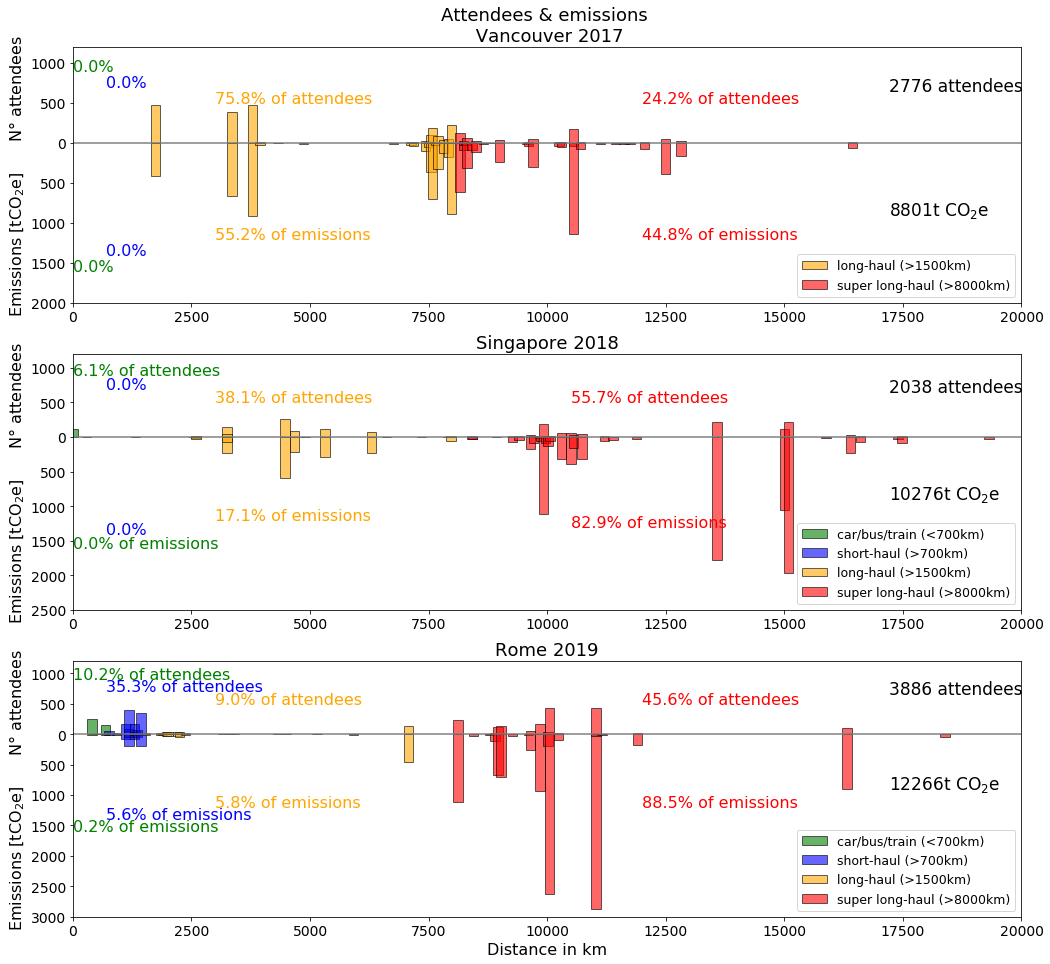

In [4]:
Locations = ['Vancouver', 'Singapore', 'Rome']
path = 'PATH_TO_DATA'

fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(17,16))


for loc in Locations: 

## read data from csv
    if loc =='Vancouver': 
        df = pd.read_excel(path+'/Vancouver_2017_data_processed.xlsx', engine='openpyxl')
        dist = np.array(df["distance to Vancouver"]) #distance in km, one-way
        dist = dist[:-2] #there are 2 nan values in the end: kick out
    if loc =='Singapore': 
        df = pd.read_excel(path+'/Singapore_2018_data_processed.xlsx', engine='openpyxl')
        dist = np.array(df["Distance to Singapore"]) #distance in km, one-way
    if loc =='Rome': 
        df = pd.read_excel(path+'/Rome_2019_data_processed.xlsx', engine='openpyxl')
        dist = np.array(df["Distance to Rome"]) #distance in km, one-way
        
    N = np.array(df["Numbers"]) # how many people
    if loc == 'Vancouver': 
        N = N[:-2] #there are 2 nan values in the end: kick out
    N_sum = np.nansum(N)
    n_countries = len(dist)#how many countries


#####################################
## number of people per type of flight
#################################

    #numbers per scenario: how many people took what kind of flights?
    #Vancouver
    print('People attending ' + loc + ': ' + str(N_sum))
    ic =sum([N for N,d in zip(N,dist) if d >= 8000])
    people_superlonghaul_percentage = round(ic/N_sum*100, 1)
    print('super long haul flights ' + loc + ': '+ str(ic))
    lh =  sum([N for N,d in zip(N,dist) if d >= 1500 and d < 8000 ])
    people_longhaul_percentage = round(lh/N_sum*100, 1)
    print('long haul flights ' + loc + ': '+ str(lh))
    sh = sum([N for N,d in zip(N,dist) if d >= 700 and d < 1500])
    people_shorthaul_percentage = round(sh/N_sum*100, 1)
    print('short haul ' + loc + ': ' + str(sh))
    ra =  sum([N for N,d in zip(N,dist) if d < 700])
    people_residence_percentage = round(ra/N_sum*100, 1)
    print('residence flights ' + loc + ': ' + str(ra))


#####################################
## emissions summed up per distance
#################################

    #num = number of people, d = distance; n*dist*2 for return *factor depending on distance
    #summed up over all people and divided by 1000
    C1ic = sum([num*d*2*0.3 for num,d in zip(N,dist) if d >= 8000])/1000 #super long haul factor: 0.3
    C1lh = sum([num*d*2*0.25 for num,d in zip(N,dist) if d >= 1500 and d < 8000])/1000 #long haul factor: 0.25
    C1sh = sum([num*d*2*0.2 for num,d in zip(N,dist) if d >= 700 and d < 1500])/1000 #short haul factor: 0.2
    C1ra = sum([num*d*2*0.06 for num,d in zip(N,dist) if d < 700])/1000 #bus/train/car: 0.06

    C1v = [C1ic,C1lh,C1sh,C1ra]
    total_emissions = sum(C1v)

    ##percentage of emissions per type of flight
    emissions_percentage_superlonghaul = round(C1ic/total_emissions*100, 1)
    emissions_percentage_longhaul = round(C1lh/total_emissions*100, 1)
    emissions_percentage_shorthaul = round(C1sh/total_emissions*100, 1)
    emissions_percentage_residence = round(C1ra/total_emissions*100, 1)


###########################################
## show the details: emissions per distance 
###########################################

    slh_emissions = np.array([num*d*2*0.3 for num,d in zip(N,dist) if d >= 8000])/1000 #super long haul factor: 0.3
    lh_emissions = np.array([num*d*2*0.25 for num,d in zip(N,dist) if d >= 1500 and d < 8000])/1000 #long haul factor: 0.25
    sh_emissions = np.array([num*d*2*0.2 for num,d in zip(N,dist) if d >= 700 and d < 1500])/1000 #short haul factor: 0.2
    re_emissions = np.array([num*d*2*0.06 for num,d in zip(N,dist) if d < 700])/1000 #residence flight factor: 0.03

    #graph, x-axis: distance of all countries (47 entries)
    #y-axis: co2 emissions: per entry in dist-vector (per country), sum up emissions
    sort_dist_index = np.argsort(dist) #get sorting index: sort distances
    dist_sorted = dist[sort_dist_index] # apply sorting to distances
    N_sorted = N[sort_dist_index] # apply to number of attendees vector
    cum_emissions_sorted = [0]*len(dist_sorted) #empty list to be filled
    for x, d in enumerate(dist_sorted):
        if d >= 8000:
            cum_emissions_sorted[x]= N_sorted[x]*d*2*0.3/1000 
        if d >= 1500 and d < 8000:
            cum_emissions_sorted[x] = N_sorted[x]*d*2*0.25/1000
        if d >= 700 and d < 1500:
            cum_emissions_sorted[x] = N_sorted[x]*d*2*0.2/1000
        if d < 700:
            cum_emissions_sorted[x] = N_sorted[x]*d*2*0.06/1000
            
###########################################
## show the details: number of people distance 
###########################################

    slh_ppl = np.array([num for num,d in zip(N,dist) if d >= 8000]) #super long haul factor: 0.3
    lh_ppl = np.array([num for num,d in zip(N,dist) if d >= 1500 and d < 8000]) #long haul factor: 0.25
    sh_ppl = np.array([num for num,d in zip(N,dist) if d >= 700 and d < 1500]) #short haul factor: 0.2
    re_ppl = np.array([num for num,d in zip(N,dist) if d < 700]) #residence flight factor: 0.03

    #graph, x-axis: distance of all countries (47 entries)
    #y-axis: number of attendees: per entry in dist-vector (per country), sum up people

        
## put it all in a dataframe ##
################################

    if loc == 'Vancouver': 
        df_sorted_Vancouver = pd.DataFrame({'Distance [km]':dist_sorted, 'Cumulative emissions [tCO$_2$e]': cum_emissions_sorted, 'Number of people attending': N_sorted })
    if loc == 'Singapore': 
        df_sorted_Singapore = pd.DataFrame({'Distance [km]':dist_sorted, 'Cumulative emissions [tCO$_2$e]': cum_emissions_sorted, 'Number of people attending': N_sorted })
    if loc == 'Rome': 
        df_sorted_Rome = pd.DataFrame({'Distance [km]':dist_sorted, 'Cumulative emissions [tCO$_2$e]': cum_emissions_sorted, 'Number of people attending': N_sorted })

############################################
## get people and emissions sorted by distance ##
############################################


    cum_emissions_sorted = np.array(cum_emissions_sorted)
    distance_residence = dist_sorted[dist_sorted < 700]
    people_residence= N_sorted[dist_sorted < 700]
    distance_short_haul = dist_sorted[np.logical_and(dist_sorted>= 700,dist_sorted < 1500)]
    people_short_haul = N_sorted[np.logical_and(dist_sorted>= 700,dist_sorted < 1500)]
    distance_long_haul = dist_sorted[np.logical_and(dist_sorted>= 1500,dist_sorted < 8000)]
    people_long_haul = N_sorted[np.logical_and(dist_sorted>= 1500,dist_sorted < 8000)]
    distance_super_long_haul = dist_sorted[dist_sorted>8000]
    people_super_long_haul = N_sorted[dist_sorted>8000]

    emissions_residence= cum_emissions_sorted[dist_sorted < 700]
    emissions_short_haul = cum_emissions_sorted[np.logical_and(dist_sorted>= 700,dist_sorted < 1500)]
    emissions_long_haul = cum_emissions_sorted[np.logical_and(dist_sorted>= 1500,dist_sorted < 8000)]
    emissions_super_long_haul = cum_emissions_sorted[dist_sorted>8000]

############################################
## plot cumulative emissions per distance ##
############################################    
    
    font_size = 16

    if loc == 'Vancouver':
        ax1.bar(x=distance_long_haul, height=people_long_haul, width = 200, color = 'orange', edgecolor='black', alpha=0.6, label='long-haul (>1500km)')
        ax1.bar(x=distance_super_long_haul, height=people_super_long_haul, width = 200, color = 'red', edgecolor='black', alpha=0.6, label='super long-haul (>8000km)')
        ax1.bar(distance_long_haul, -emissions_long_haul, width = 200, color = 'orange', edgecolor='black', alpha=0.6 )
        ax1.bar(distance_super_long_haul, -emissions_super_long_haul, width = 200, color = 'red', edgecolor='black', alpha=0.6 )

        ax1.set_xlim(0, 20000)
        ax1.set_ylim(-2000, 1200)
        ax1.set_ylabel("Emissions [tCO$_2$e]      N° attendees", fontsize=16)
        ax1.legend(fontsize=12.5, loc = 'lower right')
        
        ticks =  ax1.get_yticks()
        # set labels to absolute values and with integer representation
        ax1.set_yticklabels([int(abs(tick)) for tick in ticks])

        long_haul_line = sum(dist_sorted<1500)  #how many entries are less than 8000
        super_long_haul_line = sum(dist_sorted<8000) -0.5 #how many entries are less than 8000

        ax1.hlines(y=0, xmin=0, xmax=20000, color = 'gray',  linestyles='solid')
        #ax1.vlines(x=700, ymin=-2500, ymax=1000, color = 'black',  linestyles='dashed')
        #ax1.vlines(x=1500, ymin=-2500, ymax=1000, color = 'black',  linestyles='dashed')
        #ax1.vlines(x=8000, ymin=-2500, ymax=1000, color = 'black',  linestyles='dashed' )

        ## add text! numer of people attended and percentage of carbon output
        #super long-haul 
        ax1.text(12000, 500, str(people_superlonghaul_percentage) + '% of attendees', fontsize=font_size,  color='red')
        ax1.text(12000, -1200, str(emissions_percentage_superlonghaul) + '% of emissions', fontsize=font_size,  color='red')
        #long-haul
        ax1.text(3000, 500, str(people_longhaul_percentage) + '% of attendees', fontsize=font_size,  color='orange')
        ax1.text(3000, -1200, str(emissions_percentage_longhaul) + '% of emissions', fontsize=font_size,  color='orange')
        #short-haul
        ax1.text(700, 700, str(people_shorthaul_percentage) + '% ', fontsize=font_size,  color='blue')
        ax1.text(700, -1400, str(emissions_percentage_shorthaul) + '% ', fontsize=font_size,  color='blue')
        #sresidence
        ax1.text(10, 900, str(people_residence_percentage) + '% ', fontsize=font_size,  color='green')
        ax1.text(10, -1600, str(emissions_percentage_residence) + '% ', fontsize=font_size,  color='green')
        
        ax1.text(17200, 650, str(int(N_sum)) + ' attendees', fontsize=17,  color='black')
        ax1.text(17200, -900,  str(int(total_emissions)) + 't CO$_2$e', fontsize=17,  color='black')
       
        ax1.set_title('Attendees & emissions \n Vancouver 2017', fontsize=18)
        ax1.tick_params(labelsize=14)
        
    if loc == 'Singapore':
        ax2.bar(x=distance_residence, height=people_residence, width = 200, color = 'green', edgecolor='black', alpha=0.6, label='car/bus/train (<700km)')
        ax2.bar(x=distance_short_haul, height=people_short_haul, width = 200, color = 'blue', edgecolor='black', alpha=0.6, label='short-haul (>700km)')
        ax2.bar(x=distance_long_haul, height=people_long_haul, width = 200, color = 'orange', edgecolor='black', alpha=0.6, label='long-haul (>1500km)')
        ax2.bar(x=distance_super_long_haul, height=people_super_long_haul, width = 200, color = 'red', edgecolor='black', alpha=0.6, label='super long-haul (>8000km)')
        ax2.bar(distance_residence, -emissions_residence, width = 200, color = 'green', edgecolor='black', alpha=0.6)
        ax2.bar(distance_short_haul, -emissions_short_haul, width = 200, color = 'blue', edgecolor='black', alpha=0.6)
        ax2.bar(distance_long_haul, -emissions_long_haul, width = 200, color = 'orange', edgecolor='black', alpha=0.6)
        ax2.bar(distance_super_long_haul, -emissions_super_long_haul, width = 200, color = 'red', edgecolor='black', alpha=0.6)
        ax2.set_xlim(0, 20000)
        ax2.set_ylim(-2500, 1200)
        ax2.set_ylabel("Emissions [tCO$_2$e]      N° attendees", fontsize=16)
        ax2.legend(fontsize=12.5, loc = 'lower right')
        short_haul_line = sum(dist_sorted<700)  #how many entries are less than 8000
        long_haul_line = sum(dist_sorted<1500)  #how many entries are less than 8000
        super_long_haul_line = sum(dist_sorted<8000) -0.5 #how many entries are less than 8000

        ticks =  ax2.get_yticks()
        # set labels to absolute values and with integer representation
        ax2.set_yticklabels([int(abs(tick)) for tick in ticks])
        
        ax2.hlines(y=0, xmin=0, xmax=20000, color = 'gray',  linestyles='solid')
        #ax2.vlines(x=700, ymin=-2500, ymax=1000, color = 'black',  linestyles='dashed')
        #ax2.vlines(x=1500, ymin=-2500, ymax=1000, color = 'black',  linestyles='dashed')
        #ax2.vlines(x=8000, ymin=-2500, ymax=1000, color = 'black',  linestyles='dashed' )
        
        ## add text! numer of people attended and percentage of carbon output
        #super long-haul 
        ax2.text(10500, 500, str(people_superlonghaul_percentage) + '% of attendees', fontsize=font_size,  color='red')
        ax2.text(10500, -1300, str(emissions_percentage_superlonghaul) + '% of emissions', fontsize=font_size,  color='red')
        #long-haul
        ax2.text(3000, 500, str(people_longhaul_percentage) + '% of attendees', fontsize=font_size,  color='orange')
        ax2.text(3000, -1200, str(emissions_percentage_longhaul) + '% of emissions', fontsize=font_size,  color='orange')
        #short-haul
        ax2.text(700, 700, str(people_shorthaul_percentage) + '%', fontsize=font_size,  color='blue')
        ax2.text(700, -1400, str(emissions_percentage_shorthaul) + '%', fontsize=font_size,  color='blue')
        #sresidence
        ax2.text(10, 900, str(people_residence_percentage) + '% of attendees', fontsize=font_size,  color='green')
        ax2.text(10, -1600, str(emissions_percentage_residence) + '% of emissions', fontsize=font_size,  color='green')

        ax2.text(17200, 650, str(int(N_sum)) + ' attendees', fontsize=17,  color='black')
        ax2.text(17200, -900,  str(int(total_emissions)) + 't CO$_2$e', fontsize=17,  color='black')
        
        ax2.set_title('Singapore 2018', fontsize=18)
        ax2.tick_params(labelsize=14)
        
    if loc == 'Rome':
        ax3.bar(x=distance_residence, height=people_residence, width = 200, color = 'green', edgecolor='black', alpha=0.6, label='car/bus/train (<700km)')
        ax3.bar(x=distance_short_haul, height=people_short_haul, width = 200, color = 'blue', edgecolor='black', alpha=0.6, label='short-haul (>700km)')
        ax3.bar(x=distance_long_haul, height=people_long_haul, width = 200, color = 'orange', edgecolor='black', alpha=0.6, label='long-haul (>1500km)')
        ax3.bar(x=distance_super_long_haul, height=people_super_long_haul, width = 200, color = 'red', edgecolor='black', alpha=0.6, label='super long-haul (>8000km)')
        ax3.bar(distance_residence, -emissions_residence, width = 200, color = 'green', edgecolor='black', alpha=0.6)
        ax3.bar(distance_short_haul, -emissions_short_haul, width = 200, color = 'blue', edgecolor='black', alpha=0.6)
        ax3.bar(distance_long_haul, -emissions_long_haul, width = 200, color = 'orange', edgecolor='black', alpha=0.6)
        ax3.bar(distance_super_long_haul, -emissions_super_long_haul, width = 200, color = 'red', edgecolor='black', alpha=0.6)
        ax3.set_xlim(0, 20000)
        ax3.set_ylim(-3000, 1200)
        ax3.set_xlabel("Distance in km", fontsize=16)
        ax3.set_ylabel("Emissions [tCO$_2$e]      N° attendees", fontsize=16)
        ax3.legend(fontsize=12.5, loc = 'lower right')

        ticks =  ax3.get_yticks()
        # set labels to absolute values and with integer representation
        ax3.set_yticklabels([int(abs(tick)) for tick in ticks])
        
        ax3.hlines(y=0, xmin=0, xmax=20000, color = 'gray',  linestyles='solid')
        #ax3.vlines(x=700, ymin=-3000, ymax=1000, color = 'black',  linestyles='dashed')
        #ax3.vlines(x=1500, ymin=-3000, ymax=1000, color = 'black',  linestyles='dashed')
        #ax3.vlines(x=8000, ymin=-3000, ymax=1000, color = 'black',  linestyles='dashed')
        
        ## add text! numer of people attended and percentage of carbon output
        #super long-haul 
        ax3.text(12000, 500, str(people_superlonghaul_percentage) + '% of attendees', fontsize=font_size,  color='red')
        ax3.text(12000, -1200, str(emissions_percentage_superlonghaul) + '% of emissions', fontsize=font_size,  color='red')
        #long-haul
        ax3.text(3000, 500, str(people_longhaul_percentage) + '% of attendees', fontsize=font_size,  color='orange')
        ax3.text(3000, -1200, str(emissions_percentage_longhaul) + '% of emissions', fontsize=font_size,  color='orange')
        #short-haul
        ax3.text(700, 700, str(people_shorthaul_percentage) + '% of attendees', fontsize=font_size,  color='blue')
        ax3.text(700, -1400, str(emissions_percentage_shorthaul) + '% of emissions', fontsize=font_size,  color='blue')
        #sresidence
        ax3.text(10, 900, str(people_residence_percentage) + '% of attendees', fontsize=font_size,  color='green')
        ax3.text(10, -1600, str(emissions_percentage_residence) + '% of emissions', fontsize=font_size,  color='green')

        ax3.text(17200, 650, str(int(N_sum)) + ' attendees', fontsize=17,  color='black')
        ax3.text(17200, -900,  str(int(total_emissions)) + 't CO$_2$e', fontsize=17,  color='black')
        
        ax3.set_title('Rome 2019', fontsize=18)
        ax3.tick_params(labelsize=14)

    #for pos in ['right', 'top']:
    #    plt.gca().spines[pos].set_visible(False)
#plt.show()

plt.savefig("Attendees_emissions_Vancouver_Singapore_Rome.png", format="png", bbox_inches="tight")

### Load data of all conferences

In [19]:
## read data
path = 'PATH_TO_DATA'

df_Vancouver = pd.read_excel(path+'/Vancouver_2017_data_processed.xlsx', engine='openpyxl')
dist_Vancouver = np.array(df_Vancouver["distance to Vancouver"]) #distance in km, one-way
N_Vancouver = np.array(df_Vancouver["Numbers"]) # how many people
N_sum_Vancouver = np.nansum(N_Vancouver)
n_countries_Vancouver = len(dist_Vancouver) #how many countries 

df_Singapore = pd.read_excel(path+'/Singapore_2018_data_processed.xlsx', engine='openpyxl')
dist_Singapore = np.array(df_Singapore["Distance to Singapore"]) #distance in km, one-way
N_Singapore = np.array(df_Singapore["Numbers"]) # how many people
N_sum_Singapore = np.nansum(N_Singapore)
n_countries_Singapore = len(dist_Singapore) #how many countries 

df_Rome = pd.read_excel(path+'/Rome_2019_data_processed.xlsx', engine='openpyxl')
dist_Rome = np.array(df_Rome["Distance to Rome"]) #distance in km, one-way
N_Rome = np.array(df_Rome["Numbers"]) # how many people
N_sum_Rome = np.nansum(N_Rome)
n_countries_Rome = len(dist_Rome) #how many countries 

df_Honolulu = pd.read_excel(path+'/Honolulu_2015_data_processed.xlsx', engine='openpyxl')
dist_Honolulu = np.array(df_Honolulu["Distance to Honolulu"]) #distance in km, one-way
N_Honolulu = np.array(df_Honolulu["Numbers"]) # how many people
N_sum_Honolulu = np.nansum(N_Honolulu)
n_countries_Honolulu = len(dist_Honolulu) #how many countries 

#####################################
## number of people per type of flight
#################################

#numbers per scenario: how many people took what kind of flights?
#Vancouver
print('People attending Vancouver: ' + str(N_sum_Vancouver))
ic =sum([N for N,d in zip(N_Vancouver,dist_Vancouver) if d >= 8000])
Vancouver_people_superlonghaul_percentage = round(ic/N_sum_Vancouver*100)
print('super long haul Vancouver: ' + str(ic))
lh =  sum([N for N,d in zip(N_Vancouver,dist_Vancouver) if d < 8000])
Vancouver_people_longhaul_percentage = round(lh/N_sum_Vancouver*100)
print('long haul Vancouver: ' + str(lh))
sh = sum([N for N,d in zip(N_Vancouver,dist_Vancouver) if d >= 700 and d < 1500])
print('short haul: ' + str(sh))
ra =  sum([N for N,d in zip(N_Vancouver,dist_Vancouver) if d < 700])
print('residence flight Vancouver: ' + str(ra))

#Singapore
print('People attending Singapore: ' + str(N_sum_Singapore))
ic =sum([N for N,d in zip(N_Singapore,dist_Singapore) if d >= 8000])
Singapore_people_superlonghaul_percentage = round(ic/N_sum_Singapore*100)
print('super long haul Singapore: ' + str(ic))
lh =  sum([N for N,d in zip(N_Singapore,dist_Singapore) if d < 8000])
Singapore_people_longhaul_percentage = round(lh/N_sum_Singapore*100)
print('long haul Singapore: ' + str(lh))
sh = sum([N for N,d in zip(N_Singapore,dist_Singapore) if d >= 700 and d < 1500])
Singapore_people_shorthaul_percentage = round(sh/N_sum_Singapore*100)
print('short haul: ' + str(sh))
ra =  sum([N for N,d in zip(N_Singapore,dist_Singapore) if d < 700])
Singapore_people_residence_percentage = round(ra/N_sum_Singapore*100)
print('residence flight Singapore: ' + str(ra))

#Rome
print('People attending Rome: ' + str(N_sum_Rome))
ic =sum([N for N,d in zip(N_Rome,dist_Rome) if d >= 8000])
Rome_people_superlonghaul_percentage = round(ic/N_sum_Rome*100)
print('super long haul Rome: ' + str(ic))
lh =  sum([N for N,d in zip(N_Rome,dist_Rome) if d < 8000])
Rome_people_longhaul_percentage = round(lh/N_sum_Rome*100)
print('long haul Rome: ' + str(lh))
sh = sum([N for N,d in zip(N_Rome,dist_Rome) if d >= 700 and d < 1500])
Rome_people_shorthaul_percentage = round(sh/N_sum_Rome*100)
print('short haul: ' + str(sh))
ra =  sum([N for N,d in zip(N_Rome,dist_Rome) if d < 700])
Rome_people_residence_percentage = round(ra/N_sum_Rome*100)
print('residence flight Rome: ' + str(ra))

#Honolulu
print('People attending Honolulu: ' + str(N_sum_Honolulu))
ic =sum([N for N,d in zip(N_Honolulu,dist_Honolulu) if d >= 8000])
Honolulu_people_superlonghaul_percentage = round(ic/N_sum_Honolulu*100)
print('super long haul Honolulu: ' + str(ic))
lh =  sum([N for N,d in zip(N_Honolulu,dist_Honolulu) if d < 8000])
Honolulu_people_longhaul_percentage = round(lh/N_sum_Honolulu*100)
print('long haul Honolulu: ' + str(lh))
sh = sum([N for N,d in zip(N_Honolulu,dist_Honolulu) if d >= 700 and d < 1500])
Honolulu_people_shorthaul_percentage = round(sh/N_sum_Honolulu*100)
print('short haul: ' + str(sh))
ra =  sum([N for N,d in zip(N_Honolulu,dist_Honolulu) if d < 700])
Honolulu_people_residence_percentage = round(ra/N_sum_Honolulu*100)
print('residence flight Honolulu: ' + str(ra))

#####################################
## emissions summed up per distance
#################################

## Vancouver

#num = number of people, d = distance; n*dist*2 for return *factor depending on distance
#summed up over all people and divided by 1000
C1ic_Vancouver = sum([num*d*2*0.3 for num,d in zip(N_Vancouver,dist_Vancouver) if d >= 8000])/1000 #super long haul factor: 0.3
C1lh_Vancouver = sum([num*d*2*0.25 for num,d in zip(N_Vancouver,dist_Vancouver) if d >= 1500 and d < 8000])/1000 #long haul factor: 0.25
C1sh_Vancouver = sum([num*d*2*0.2 for num,d in zip(N_Vancouver,dist_Vancouver) if d >= 700 and d < 1500])/1000 #short haul factor: 0.2
C1ra_Vancouver = sum([num*d*2*0.03 for num,d in zip(N_Vancouver,dist_Vancouver) if d < 700])/1000 #residence flight factor: 0.03

C1v_Vancouver = [C1ic_Vancouver,C1lh_Vancouver,C1sh_Vancouver,C1ra_Vancouver]
total_emissions_Vancouver = sum(C1v_Vancouver)

##percentage of emissions per type of flight
Vancouver_emissions_percentage_superlonghaul = round(C1ic_Vancouver/total_emissions_Vancouver*100)
Vancouver_emissions_percentage_longhaul = round(C1lh_Vancouver/total_emissions_Vancouver*100)
Vancouver_emissions_percentage_shorthaul = round(C1sh_Vancouver/total_emissions_Vancouver*100)


## Singapore

#num = number of people, d = distance; n*dist*2 for return *factor depending on distance
#summed up over all people and divided by 1000
C1ic_Singapore = sum([num*d*2*0.3 for num,d in zip(N_Singapore,dist_Singapore) if d >= 8000])/1000 #super long haul factor: 0.3
C1lh_Singapore = sum([num*d*2*0.25 for num,d in zip(N_Singapore,dist_Singapore) if d >= 1500 and d < 8000])/1000 #long haul factor: 0.25
C1sh_Singapore = sum([num*d*2*0.2 for num,d in zip(N_Singapore,dist_Singapore) if d >= 700 and d < 1500])/1000 #short haul factor: 0.2
C1ra_Singapore = sum([num*d*2*0.03 for num,d in zip(N_Singapore,dist_Singapore) if d < 700])/1000 #residence flight factor: 0.03

C1v_Singapore = [C1ic_Singapore,C1lh_Singapore,C1sh_Singapore,C1ra_Singapore]
total_emissions_Singapore = sum(C1v_Singapore)

##percentage of emissions per type of flight
Singapore_emissions_percentage_superlonghaul = round(C1ic_Singapore/total_emissions_Singapore*100)
Singapore_emissions_percentage_longhaul = round(C1lh_Singapore/total_emissions_Singapore*100)
Singapore_emissions_percentage_shorthaul = round(C1sh_Singapore/total_emissions_Singapore*100)

## Rome

#num = number of people, d = distance; n*dist*2 for return *factor depending on distance
#summed up over all people and divided by 1000
C1ic_Rome = sum([num*d*2*0.3 for num,d in zip(N_Rome,dist_Rome) if d >= 8000])/1000 #super long haul factor: 0.3
C1lh_Rome = sum([num*d*2*0.25 for num,d in zip(N_Rome,dist_Rome) if d >= 1500 and d < 8000])/1000 #long haul factor: 0.25
C1sh_Rome = sum([num*d*2*0.2 for num,d in zip(N_Rome,dist_Rome) if d >= 700 and d < 1500])/1000 #short haul factor: 0.2
C1ra_Rome = sum([num*d*2*0.03 for num,d in zip(N_Rome,dist_Rome) if d < 700])/1000 #residence flight factor: 0.03

C1v_Rome = [C1ic_Rome,C1lh_Rome,C1sh_Rome,C1ra_Rome]
total_emissions_Rome = sum(C1v_Rome)

##percentage of emissions per type of flight
Rome_emissions_percentage_superlonghaul = round(C1ic_Rome/total_emissions_Rome*100)
Rome_emissions_percentage_longhaul = round(C1lh_Rome/total_emissions_Rome*100)
Rome_emissions_percentage_shorthaul = round(C1sh_Rome/total_emissions_Rome*100)


## Honolulu

#num = number of people, d = distance; n*dist*2 for return *factor depending on distance
#summed up over all people and divided by 1000
C1ic_Honolulu = sum([num*d*2*0.3 for num,d in zip(N_Honolulu,dist_Honolulu) if d >= 8000])/1000 #super long haul factor: 0.3
C1lh_Honolulu = sum([num*d*2*0.25 for num,d in zip(N_Honolulu,dist_Honolulu) if d >= 1500 and d < 8000])/1000 #long haul factor: 0.25
C1sh_Honolulu = sum([num*d*2*0.2 for num,d in zip(N_Honolulu,dist_Honolulu) if d >= 700 and d < 1500])/1000 #short haul factor: 0.2
C1ra_Honolulu = sum([num*d*2*0.03 for num,d in zip(N_Honolulu,dist_Honolulu) if d < 700])/1000 #residence flight factor: 0.03

C1v_Honolulu = [C1ic_Honolulu,C1lh_Honolulu,C1sh_Honolulu,C1ra_Honolulu]
total_emissions_Honolulu = sum(C1v_Honolulu)

##percentage of emissions per type of flight
Honolulu_emissions_percentage_superlonghaul = round(C1ic_Honolulu/total_emissions_Honolulu*100)
Honolulu_emissions_percentage_longhaul = round(C1lh_Honolulu/total_emissions_Honolulu*100)
Honolulu_emissions_percentage_shorthaul = round(C1sh_Honolulu/total_emissions_Honolulu*100)

People attending Vancouver: 2776.0
super long haul Vancouver: 672.0
long haul Vancouver: 2104.0
short haul: 0
residence flight Vancouver: 0
People attending Singapore: 2038
super long haul Singapore: 1136
long haul Singapore: 902
short haul: 1
residence flight Singapore: 124
People attending Rome: 3886
super long haul Rome: 1771
long haul Rome: 2115
short haul: 1370
residence flight Rome: 395
People attending Honolulu: 2897
super long haul Honolulu: 1621
long haul Honolulu: 1276
short haul: 0
residence flight Honolulu: 0


## Plot all emissions of all conferences in one plot

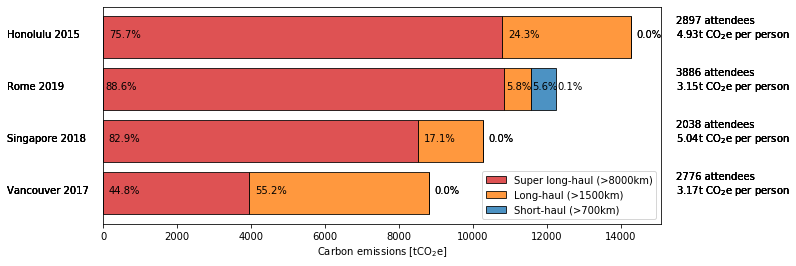

In [20]:
fig,ax = plt.subplots(1,1,figsize=(10,4))

ax.barh(1,C1ic_Vancouver,color="C3",label="Super long-haul (>8000km)",edgecolor="k",alpha=0.8)
ax.barh(1,C1lh_Vancouver, left=C1ic_Vancouver,color="C1",label="Long-haul (>1500km)",edgecolor="k",alpha=0.8)
ax.barh(1,C1sh_Vancouver,left=C1ic_Vancouver+C1lh_Vancouver,color="C0",label="Short-haul (>700km)",edgecolor="k",alpha=0.8)

xs = 0
for x in C1v_Vancouver:
    ax.text(xs+150,1,"%2.1f%%" % (x/total_emissions_Vancouver*100))
    xs = xs + x
    ax.text(-2600, 1, "Vancouver 2017" )
    ax.text(15500, 1, str(int(N_sum_Vancouver)) + " attendees \n" + str(round(total_emissions_Vancouver/N_sum_Vancouver, 2)) + 't CO$_2$e per person')
    
ax.barh(2,C1ic_Singapore,color="C3",edgecolor="k",alpha=0.8)
ax.barh(2,C1lh_Singapore, left=C1ic_Singapore,color="C1",edgecolor="k",alpha=0.8)
ax.barh(2,C1sh_Singapore,left=C1ic_Singapore+C1lh_Singapore,color="C0",edgecolor="k",alpha=0.8)

xs = 0
for x in C1v_Singapore:
    ax.text(xs+150,2, "%2.1f%%" % (x/total_emissions_Singapore*100))
    xs = xs + x
    ax.text(-2600, 2, "Singapore 2018" )
    ax.text(15500, 2, str(N_sum_Singapore) + " attendees \n" + str(round(total_emissions_Singapore/N_sum_Singapore, 2)) + 't CO$_2$e per person')
    
ax.barh(3,C1ic_Rome,color="C3",edgecolor="k",alpha=0.8)
ax.barh(3,C1lh_Rome, left=C1ic_Rome,color="C1",edgecolor="k",alpha=0.8)
ax.barh(3,C1sh_Rome,left=C1ic_Rome+C1lh_Rome,color="C0",edgecolor="k",alpha=0.8)
ax.legend(loc=4)

xs = 0
for x in C1v_Rome:
    ax.text(xs+50,3,"%2.1f%%" % (x/total_emissions_Rome*100))
    xs = xs + x
    ax.text(-2600, 3, "Rome 2019" )
    ax.text(15500, 3, str(N_sum_Rome) + " attendees \n" + str(round(total_emissions_Rome/N_sum_Rome, 2)) + 't CO$_2$e per person')

ax.barh(4,C1ic_Honolulu,color="C3",edgecolor="k",alpha=0.8)
ax.barh(4,C1lh_Honolulu, left=C1ic_Honolulu,color="C1",edgecolor="k",alpha=0.8)
ax.barh(4,C1sh_Honolulu,left=C1ic_Honolulu+C1lh_Honolulu,color="C0",edgecolor="k",alpha=0.8)

xs = 0
for x in C1v_Honolulu:
    ax.text(xs+150,4,"%2.1f%%" % (x/total_emissions_Honolulu*100))
    xs = xs + x
    ax.text(-2600, 4, "Honolulu 2015" )
    ax.text(15500, 4, str(N_sum_Honolulu) + " attendees \n" + str(round(total_emissions_Honolulu/N_sum_Honolulu, 2)) + 't CO$_2$e per person')
    
ax.set_xlabel("Carbon emissions [tCO$_2$e]")

ax.set_xlim(0,15100)
ax.set_yticks([])

plt.savefig("Total_emissions_Honolulu_Vancouver_Singapore_Rome.pdf", format="pdf", bbox_inches="tight")

#plt.tight_layout()
plt.show()